# 1. Imports

#  Importing Libraries

This section imports all required libraries for the project:

- **NumPy & Matplotlib** → numerical computation and visualization  
- **Scikit-learn** → dataset generation, preprocessing, and classical model  
- **Qiskit** → quantum circuit simulation and noise modeling  
- **SciPy** → optimization of quantum circuit parameters  

These libraries together enable the implementation of both classical and quantum machine learning models.

In [1]:
!pip install qiskit qiskit-aer --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.0 MB/s eta 0:00:00


In [2]:
# ==========================================
# CORE LIBRARIES
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# MACHINE LEARNING
# ==========================================
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==========================================
# QUANTUM
# ==========================================
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# ==========================================
# OPTIMIZATION
# ==========================================
from scipy.optimize import minimize

# 2. Dataset

#  Dataset Generation

A synthetic binary classification dataset is generated using `make_classification`.

### Key Parameters:
- **n_features = 2** → allows visualization in 2D  
- **class_sep = 0.4** → reduces separation between classes (harder problem)  
- **flip_y = 0.2** → introduces label noise  

### Purpose:
To create a **non-trivial and realistic dataset** where classification is challenging, enabling meaningful comparison between classical and quantum models.

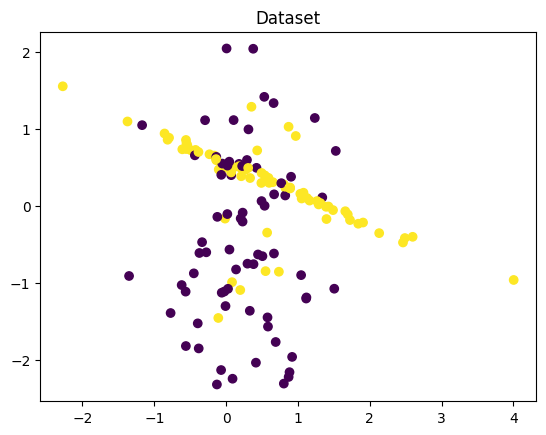

In [3]:
# ==========================================
# DATA GENERATION
# ==========================================
X, y = make_classification(
    n_samples=150,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.4,
    flip_y=0.2,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset")
plt.show()

# Dataset Visualization

A scatter plot is used to visualize the dataset.

### Interpretation:
- Each point represents a sample  
- Colors represent class labels  
- Overlap between classes indicates **non-linear separability**

This helps understand the difficulty of the classification task before training models.

# 3. Preprocessing

# Data Preprocessing

The dataset is scaled and split into training and testing sets.

### Steps:
- **MinMax Scaling → [0, π]**
  - Required for quantum circuits (rotation angles)
- **Train-Test Split**
  - 80% training, 20% testing

### Purpose:
Ensure compatibility with quantum encoding and enable fair model evaluation.

In [4]:
# ==========================================
# SCALING + SPLIT
# ==========================================
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 4. Classical model

# Classical Baseline Model

A Logistic Regression model is trained as a baseline.

### Why Logistic Regression?
- Simple and interpretable  
- Works well for linearly separable data  
- Provides a benchmark to compare quantum performance  

### Output:
Accuracy on the test set, used as a reference for evaluating the quantum model.

In [5]:
# ==========================================
# CLASSICAL BASELINE
# ==========================================
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_classical = model.predict(X_test)
print("Classical Accuracy:", accuracy_score(y_test, y_pred_classical))

Classical Accuracy: 0.8


# 5. Quantum setup

# Quantum Simulator Setup

The AerSimulator from Qiskit is used to simulate quantum circuits.

### Purpose:
- Execute quantum circuits on a classical backend  
- Allows experimentation without real quantum hardware  

This enables development and testing of the Variational Quantum Classifier (VQC).

In [6]:
# ==========================================
# QUANTUM SIMULATOR
# ==========================================
simulator = AerSimulator()

# 6. Multi-Layer VQC

# Variational Quantum Circuit (VQC)

This function defines the parameterized quantum circuit.

### Components:
- **Feature Encoding**
  - Input features encoded using RY rotations
- **Trainable Parameters**
  - Parameterized RY gates (θ)
- **Entanglement**
  - CNOT gate introduces correlation between qubits
- **Measurement**
  - Outputs probabilities for classification

### Purpose:
Acts as the **quantum model**, where parameters are optimized during training.

In [7]:
# ==========================================
# VARIATIONAL CIRCUIT
# ==========================================

def variational_circuit(x, theta, n_layers):
    qc = QuantumCircuit(2)

    qc.ry(x[0], 0)
    qc.ry(x[1], 1)

    idx = 0

    for _ in range(n_layers):
        qc.ry(theta[idx], 0)
        qc.ry(theta[idx + 1], 1)
        qc.cx(0, 1)
        idx += 2

    qc.measure_all()
    return qc
def variational_circuit(x, theta, n_layers):
    qc = QuantumCircuit(2)

    qc.ry(x[0], 0)
    qc.ry(x[1], 1)

    idx = 0

    for _ in range(n_layers):
        qc.ry(theta[idx], 0)
        qc.ry(theta[idx + 1], 1)
        qc.cx(0, 1)
        idx += 2

    qc.measure_all()
    return qc

# 7. Prediction

# Quantum Prediction Function

This function evaluates the quantum circuit and computes prediction probabilities.

### Steps:
1. Run quantum circuit using simulator  
2. Extract measurement counts  
3. Compute probability of class 1  

### Decision Rule:
- If probability > 0.5 → Class 1  
- Else → Class 0  

This converts quantum outputs into usable predictions.

In [8]:
# ==========================================
# PREDICTION FUNCTIONS
# ==========================================
def predict_proba(x, theta):
    qc = variational_circuit(x, theta, n_layers)

    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()

    prob_1 = (
        counts.get('01', 0) +
        counts.get('11', 0)
    ) / 1024

    return prob_1


def predict(x, theta):
    return 1 if predict_proba(x, theta) > 0.5 else 0

# 8. Loss Function

# Loss Tracking Initialization

A list is initialized to store loss values during training.

### Purpose:
- Track optimization progress  
- Visualize convergence behavior  
- Analyze training performance  

This is essential for understanding how the quantum model learns.

In [10]:
# ==========================================
# LOSS TRACKING
# ==========================================
loss_values = []

# Loss Function

The loss function computes Mean Squared Error (MSE) between:

- True labels  
- Predicted probabilities  

### Why MSE?
- Simple and effective for probability-based outputs  
- Smooth and suitable for optimization  

### Additional Feature:
- Loss values are stored for plotting the training curve

This function guides the optimization of quantum parameters.

In [12]:
# ==========================================
# LOSS FUNCTION
# ==========================================

def loss_function(theta):
    loss = 0

    for x, y_true in zip(X_train, y_train):
        prob = predict_proba(x, theta)
        loss += (y_true - prob) ** 2

    loss = loss / len(X_train)
    loss_values.append(loss)

    return loss

# 9. Training block

# Training the Quantum Model

The quantum circuit parameters are optimized using the COBYLA optimizer.

### Steps:
- Initialize random parameters  
- Minimize the loss function  
- Update parameters iteratively  

### Output:
- Optimized parameters (θ*)

### Purpose:
Train the quantum model to fit the dataset.

In [13]:
n_layers = 3
num_params = 2 * n_layers

initial_theta = np.random.rand(num_params)

result = minimize(
    loss_function,
    initial_theta,
    method='COBYLA',
    options={'maxiter': 50}
)

optimal_theta = result.x

# after training

In [14]:
y_pred_quantum = []

for x in X_test:
    y_pred_quantum.append(predict(x, optimal_theta))

y_pred_quantum = np.array(y_pred_quantum)

accuracy_quantum = accuracy_score(y_test, y_pred_quantum)

print("Quantum Accuracy:", accuracy_quantum)

Quantum Accuracy: 0.4


# 10. Loss curve

# Training Loss Curve

The loss values collected during training are plotted.

### Interpretation:
- Decreasing curve → model is learning  
- Plateau → model has converged  

This visualization helps analyze optimization performance.

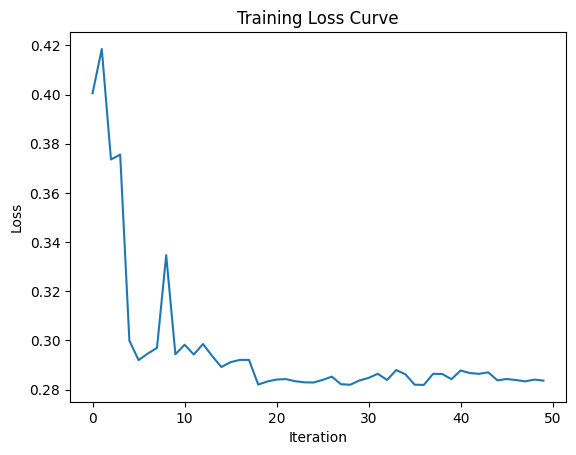

In [15]:
# ==========================================
# LOSS CURVE
# ==========================================
plt.plot(loss_values)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# 11. Quantum Evaluation

# Quantum Model Evaluation

The trained quantum model is evaluated on the test set.

### Steps:
- Generate predictions for test data  
- Compute accuracy  

### Purpose:
Measure how well the quantum model generalizes to unseen data.

In [16]:
# ==========================================
# QUANTUM ACCURACY
# ==========================================
y_pred_quantum = []

for x in X_test:
    y_pred_quantum.append(predict(x, optimal_theta))

y_pred_quantum = np.array(y_pred_quantum)

accuracy_quantum = accuracy_score(y_test, y_pred_quantum)
print("Quantum Accuracy:", accuracy_quantum)

Quantum Accuracy: 0.43333333333333335


# 12. Noise model

# Noise Model

A depolarizing noise model is introduced to simulate real quantum hardware.

### Noise Types:
- Single-qubit error  
- Two-qubit error  

### Purpose:
Evaluate how noise affects quantum model performance.

In [17]:
# ==========================================
# NOISE MODEL
# ==========================================
noise_model = NoiseModel()

error_1 = depolarizing_error(0.1, 1)
error_2 = depolarizing_error(0.1, 2)

noise_model.add_all_qubit_quantum_error(error_1, ['ry'])
noise_model.add_all_qubit_quantum_error(error_2, ['cx'])

# 13. Noise prediction

# Noisy Quantum Prediction

Predictions are generated using the noisy quantum simulator.

### Purpose:
- Compare ideal vs noisy performance  
- Analyze robustness of the quantum model  

This simulates real-world quantum conditions.

In [18]:
def predict_proba_noisy(x, theta):
    qc = variational_circuit(x, theta, n_layers)

    result = simulator.run(
        qc,
        shots=1024,
        noise_model=noise_model
    ).result()

    counts = result.get_counts()

    prob_1 = (
        counts.get('01', 0) +
        counts.get('11', 0)
    ) / 1024

    return prob_1


def predict_noisy(x, theta):
    return 1 if predict_proba_noisy(x, theta) > 0.5 else 0

# 14. Noisy Evaluation

In [19]:
y_pred_noisy = []

for x in X_test:
    y_pred_noisy.append(predict_noisy(x, optimal_theta))

y_pred_noisy = np.array(y_pred_noisy)

accuracy_noisy = accuracy_score(y_test, y_pred_noisy)
print("Noisy Quantum Accuracy:", accuracy_noisy)

Noisy Quantum Accuracy: 0.43333333333333335


# 15. Final comparison

# Model Comparison

A bar chart compares:

- Classical model  
- Quantum model (ideal)  
- Quantum model (noisy)  

### Purpose:
Provide a clear performance comparison across approaches.

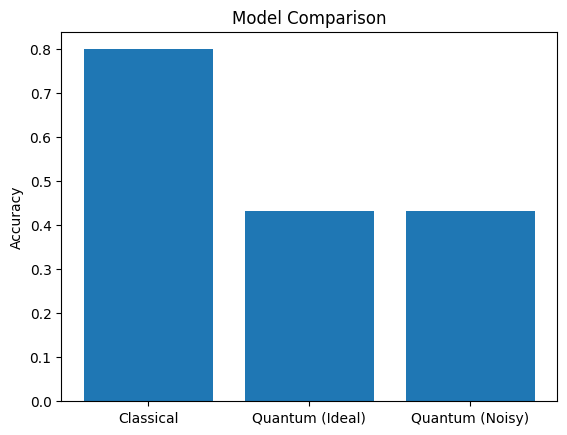

In [20]:
# ==========================================
# FINAL COMPARISON
# ==========================================
models = ['Classical', 'Quantum (Ideal)', 'Quantum (Noisy)']

accuracies = [
    accuracy_score(y_test, y_pred_classical),
    accuracy_quantum,
    accuracy_noisy
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

# 16. Decision boundaries

# Decision Boundary Visualization

The decision boundary of the quantum model is visualized.

### Interpretation:
- Colors represent probability of class 1  
- Smooth gradients indicate uncertainty  
- Sharp transitions indicate strong classification  

### Purpose:
Understand how the quantum model separates data in feature space.

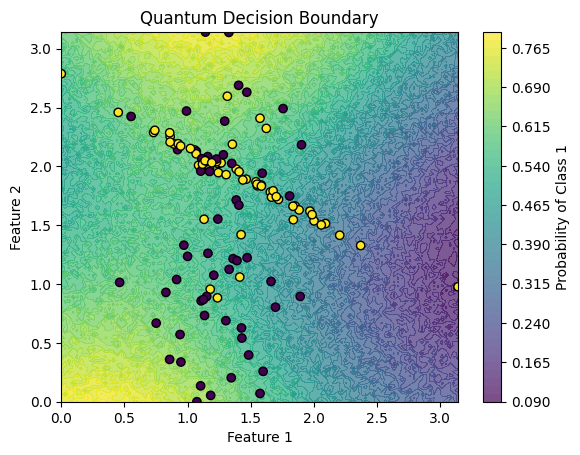

In [21]:
# ==========================================
# DECISION BOUNDARY
# ==========================================
xx, yy = np.meshgrid(
    np.linspace(0, np.pi, 100),
    np.linspace(0, np.pi, 100)
)

Z = []

for x1, x2 in zip(xx.ravel(), yy.ravel()):
    prob = predict_proba([x1, x2], optimal_theta)
    Z.append(prob)

Z = np.array(Z).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, alpha=0.7)
plt.colorbar(label="Probability of Class 1")

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')

plt.title("Quantum Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()